In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str


graph_builder = StateGraph(AgentState)

/Users/leehk/.pyenv/versions/tutorial-langchain/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class RouteResponse(BaseModel):
    target: Literal['income_tax', 'eastate_tax', 'llm'] = Field(
        description="답변할 대상"
    )

router_system_prompt = """
당신은 사용자의 질문을 'income_tax', 'llm' 또는 'eastate_tax'로 연결(routing)하는 데 전문가입니다.
아래 규칙에 따라 라우팅하세요.

규칙
'income_tax': 한국의 소득세법
'eastate_tax': 한국의 종합부동산세법
'llm': 간단한 질문
"""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatOpenAI(
    model="gpt-4o-mini"
).with_structured_output(RouteResponse)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | router_llm
    response = router_chain.invoke({'query': query})
    print(f"router: {response}")
    return response.target


In [3]:
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [4]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState):
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    answer = llm_chain.invoke(query)
    print(f'call_llm: {answer}')
    return {'answer': answer}

In [5]:
from income_tax_graph import graph as income_tax_agent
from eastate_tax_graph import graph as eastate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('eastate_tax', eastate_tax_agent)
graph_builder.add_node('llm', call_llm)

In [6]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'eastate_tax': 'eastate_tax',
        'llm': 'llm'
    }
)

graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('eastate_tax', END)
graph_builder.add_edge('llm', END)

In [7]:
graph = graph_builder.compile()

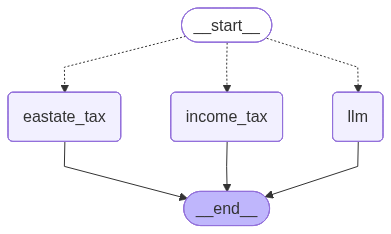

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
"""소득세"""
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

router: target='income_tax'
context == [Document(id='19b1e5df-ff9a-4d65-957e-fbf0687422f1', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21., 일부개정]\n재정경제부 (세제실제1과양도소득세) 044-215-4312\n재정경제부 (소득세제과근로소득) 044-215-4216\n재정경제부 (금융세제과이자소득, 배당소득) 044-215-4233\n재정경제부 (소득세제과사업소득, 기타소득) 044-215-4217\n재정경제부 (국제조세제도과비거주자) 044-215-4651'), Document(id='f37836ae-3ac7-43b1-9847-79f84fe08580', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21., 일부개정]\n재정경제부 (세제실제1과양도소득세) 044-215-4312\n재정경제부 (소득세제과근로소득) 044-215-4216\n재정경제부 (금융세제과이자소득, 배당소득) 044-215-4233\n재정경제부 (소득세제과사업소득, 기타소득) 044-215-4217\n재정경제부 (국제조세제도과비거주자) 044-215-4651'), Document(id='76f23259-5078-40ad-ab80-39768b1d95ff', metadata={'source': './documents/income_tax.txt'}, page_content='1. 종합소득\n법제처 2 국가법령정보센터\n소득세법\n이 법에 따라 과세되는 모든 소득에서 제2호 및 제3호에 따른 소득을 제외한 소득으로서 다음 각 목의 소득을 합산한 것\n가. 이자소득\n나. 배당소득\n다. 사업소득\n라. 근로소득\n마.

{'query': '소득세란 무엇인가요?',
 'context': [Document(id='19b1e5df-ff9a-4d65-957e-fbf0687422f1', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21., 일부개정]\n재정경제부 (세제실제1과양도소득세) 044-215-4312\n재정경제부 (소득세제과근로소득) 044-215-4216\n재정경제부 (금융세제과이자소득, 배당소득) 044-215-4233\n재정경제부 (소득세제과사업소득, 기타소득) 044-215-4217\n재정경제부 (국제조세제도과비거주자) 044-215-4651'),
  Document(id='f37836ae-3ac7-43b1-9847-79f84fe08580', metadata={'source': './documents/income_tax.txt'}, page_content='소득세법\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21., 일부개정]\n재정경제부 (세제실제1과양도소득세) 044-215-4312\n재정경제부 (소득세제과근로소득) 044-215-4216\n재정경제부 (금융세제과이자소득, 배당소득) 044-215-4233\n재정경제부 (소득세제과사업소득, 기타소득) 044-215-4217\n재정경제부 (국제조세제도과비거주자) 044-215-4651'),
  Document(id='76f23259-5078-40ad-ab80-39768b1d95ff', metadata={'source': './documents/income_tax.txt'}, page_content='1. 종합소득\n법제처 2 국가법령정보센터\n소득세법\n이 법에 따라 과세되는 모든 소득에서 제2호 및 제3호에 따른 소득을 제외한 소득으로서 다음 각 목의 소득을 합산한 것\n가. 이자소득\n나. 배당소득\n다. 사업소득\n라. 근로소득\n

In [10]:
"""종합소득세"""
initial_state = {'query': '15억 아파트는 세금을 얼마나 내나요?'}
graph.invoke(initial_state)

router: target='eastate_tax'
tax_market_ratio web search: {'query': '오늘 날짜(2026-05-08)에 해당하는 주택 공시가격 공정시장가액비율은 몇 %인가요?', 'follow_up_questions': None, 'answer': '2026년 오늘 주택 공시가격 공정시장가액비율은 60%입니다. 이 비율은 재산세 계산에 사용됩니다. 비율이 높을수록 세금 부담이 커집니다.', 'images': ['https://on-estate.com/wp-content/uploads/2026/03/%EC%A0%9C%EB%AA%A9%EC%9D%84-%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94.-13-1024x724.jpg', 'https://www.joseilbo.com/gisa_img_origin/17768184131776818413_rozzhj_origin.png', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://img.newspim.com/news/2025/08/18/2508181723068400.jpg', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMjU1/MDAxNzQxMjA5NzE0MTI3.yjvDGrS5xiH4fyDyePIh2e2b3MPgLCUEHcVtXXnSJ7cg.75H1A46b_weyUYG1zwwo30qQid4SRPppJJMwTsZ5ObIg.PNG/image.png?type=w800'], 'results': [{'url': 'https://contents.premium.naver.com/doodle2/seobi08

{'query': '15억 아파트는 세금을 얼마나 내나요?',
 'answer': '주어진 정보를 바탕으로 사용자의 경우에 해당하는 종합부동산세를 계산해볼 수 있습니다. 사용자는 주택을 1채 소유한 것으로 가정하므로 "2주택 이하"의 세율을 적용합니다.\n\n주어진 계산을 정리하면 다음과 같습니다:\n\n1. **과세표준**: 3억 원 (주택 공시가격 15억 - 공제금 12억)\n2. **공정시장가액비율을 적용한 실제 과세기준**: 1.8억 원 (3억 원 × 60%)\n\n**세율 적용**:\n- "2주택 이하"의 경우, 과세기준 금액이 1.8억 원이므로 3억 원 이하의 금액은 12분의 5 세율을 적용합니다.\n\n\\[\n\\text{종합부동산세} = 1.8억 \\times \\left(\\frac{5}{12}\\right) = 0.75억 \\times 1.8 = 0.15억 원\n\\]\n\n따라서, 사용자가 내야 할 종합부동산세는 약 0.15억 원입니다.'}

In [12]:
"""기타-간단한 질문"""
initial_state = {'query': '강남역 맛집 추천'}
graph.invoke(initial_state)

router: target='llm'
call_llm: 강남역 주변에는 맛있는 음식점이 많이 있습니다. 몇 가지 추천해드릴게요.

1. **성수이영돈까스** - 일본식 돈까스를 전문으로 하는 집으로, 바삭한 튀김옷과 촉촉한 고기가 일품입니다.

2. **마포갈매기** - 갈매기살과 다양한 고기를 구워 먹을 수 있는 맛집으로, 고기의 질이 꽤 좋습니다.

3. **청담동 말죽거리 소고기국밥** - 진한 국물의 소고기국밥을 맛볼 수 있는 곳으로, 재료의 신선함이 돋보입니다.

4. **밀리오레 라멘** - 진한 국물과 쫄깃한 면발로 유명한 라멘집으로, 일본 스타일의 라멘을 즐길 수 있습니다.

5. **오모리 김치찌개** - 푸짐한 양과 매콤한 맛이 특징인 김치찌개 전문점으로, 막걸리와 함께 먹기 좋은 메뉴입니다.

6. **뼈도치** - 다양한 족발과 보쌈을 제공하는 곳으로, 쫄깃한 식감과 함께 맥주와 잘 어울립니다.

이 외에도 강남역 주변에는 다양한 음식점들이 많으니, 기분에 맞는 음식을 찾아보세요!


{'query': '강남역 맛집 추천',
 'answer': '강남역 주변에는 맛있는 음식점이 많이 있습니다. 몇 가지 추천해드릴게요.\n\n1. **성수이영돈까스** - 일본식 돈까스를 전문으로 하는 집으로, 바삭한 튀김옷과 촉촉한 고기가 일품입니다.\n\n2. **마포갈매기** - 갈매기살과 다양한 고기를 구워 먹을 수 있는 맛집으로, 고기의 질이 꽤 좋습니다.\n\n3. **청담동 말죽거리 소고기국밥** - 진한 국물의 소고기국밥을 맛볼 수 있는 곳으로, 재료의 신선함이 돋보입니다.\n\n4. **밀리오레 라멘** - 진한 국물과 쫄깃한 면발로 유명한 라멘집으로, 일본 스타일의 라멘을 즐길 수 있습니다.\n\n5. **오모리 김치찌개** - 푸짐한 양과 매콤한 맛이 특징인 김치찌개 전문점으로, 막걸리와 함께 먹기 좋은 메뉴입니다.\n\n6. **뼈도치** - 다양한 족발과 보쌈을 제공하는 곳으로, 쫄깃한 식감과 함께 맥주와 잘 어울립니다.\n\n이 외에도 강남역 주변에는 다양한 음식점들이 많으니, 기분에 맞는 음식을 찾아보세요!'}